<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/CNN_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt


transform = transforms.ToTensor()
#image to tensors
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 880kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


**CNN intialization**

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            7 * 7 * 64,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

Dilation
Effective Size = Dilation × (Kernel Size - 1) + 1

---




In [ ]:
model = CNN()

print(model)

images, labels = next(iter(train_loader))

print("Input:", images.shape)

output = model(images)

print("Output:", output.shape)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Input: torch.Size([64, 1, 28, 28])
Output: torch.Size([64, 10])


In [ ]:
cross_loss = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

train_loss_history = []
train_acc_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward propagation
        outputs = model(images)

        # Calculate loss
        loss = cross_loss(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)




    average_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    train_loss_history.append(average_loss)
    train_acc_history.append(accuracy)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/10 | Loss: 0.1904 | Accuracy: 94.27%
Epoch 2/10 | Loss: 0.0529 | Accuracy: 98.39%
Epoch 3/10 | Loss: 0.0352 | Accuracy: 98.88%
Epoch 4/10 | Loss: 0.0265 | Accuracy: 99.16%
Epoch 5/10 | Loss: 0.0210 | Accuracy: 99.33%
Epoch 6/10 | Loss: 0.0155 | Accuracy: 99.46%
Epoch 7/10 | Loss: 0.0141 | Accuracy: 99.55%
Epoch 8/10 | Loss: 0.0110 | Accuracy: 99.63%
Epoch 9/10 | Loss: 0.0087 | Accuracy: 99.69%
Epoch 10/10 | Loss: 0.0055 | Accuracy: 99.82%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.10%


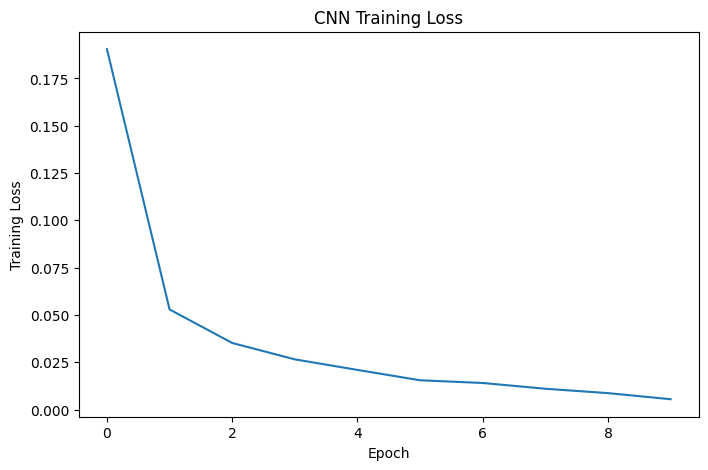

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.show()